<a href="https://colab.research.google.com/github/NicolasZarateC/Analitica-de-Negocios/blob/main/Parcial_2_Nicolas_Zarate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Parcial 2 - Nicolas Zarate**

Cargar Librerias y Paquetes de Trabajo

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
import numpy as np #Permite convertir los dataframe en array para poder hacer operaciones matemáticas
import pandas as pd #Permite comunicarnos con la base de datos en excel
import matplotlib.pyplot as plt #Este es el Graficador
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
nxl='/content/drive/MyDrive/Eafit/Colab Notebooks - Analítica de Negocios/Bases de Datos/7. BGD and Cost of Debt - Feb 2023_Int.xlsx'
XDB=pd.read_excel(nxl)
#print(XDB.columns)
XDB=XDB[['ESG Score (2022)','Environmental Pillar Score( 2022)','Social Pillar Score (2022)','Governance Pillar Socre (2022)',' WACC Short Term Debt Cost (2022)','WACC Long Term Debt Cost (2022)', 'Board Gender Diversity (2022)',' Board Size (2022)','Female on Board (2022)', 'Independant Board Members Score (2022)','Executive Members Gender Diversity (2022)']]
XDB=XDB.dropna()
display(XDB)

#MODELO 1
#VAIRABLE ENTRADA
XD=np.array(XDB[['ESG Score (2022)','Environmental Pillar Score( 2022)','Social Pillar Score (2022)','Governance Pillar Socre (2022)','Board Gender Diversity (2022)',' Board Size (2022)','Female on Board (2022)', 'Independant Board Members Score (2022)','Executive Members Gender Diversity (2022)']])
#VARIABLE SALIDA
yd=np.array(XDB[[' WACC Short Term Debt Cost (2022)',]])
#Normalizacion de variables
XDn=XD/np.max(XD,axis=0)
ydn=yd
print("Los datos de entrada normalizados son:\n",XDn)


#MODELO 2
#VAIRABLE ENTRADA
XD=np.array(XDB[['ESG Score (2022)','Environmental Pillar Score( 2022)','Social Pillar Score (2022)','Governance Pillar Socre (2022)', 'Board Gender Diversity (2022)',' Board Size (2022)','Female on Board (2022)', 'Independant Board Members Score (2022)','Executive Members Gender Diversity (2022)']])
#VARIABLE SALIDA
yd2=np.array(XDB[['WACC Long Term Debt Cost (2022)',]])
#Normalizacion de variables
XDn=XD/np.max(XD,axis=0)
ydn2=yd
print("Los datos de entrada normalizados son:\n",XDn)

,ESG Score (2022),Environmental Pillar Score( 2022),Social Pillar Score (2022),Governance Pillar Socre (2022),WACC Short Term Debt Cost (2022),WACC Long Term Debt Cost (2022),Board Gender Diversity (2022),Board Size (2022),Female on Board (2022),Independant Board Members Score (2022),Executive Members Gender Diversity (2022)
0,47.373394,3.176714,44.427314,69.111111,0.027338,0.016627,50.000000,10.0,20.000000,90.000000,25.000000
1,64.897646,57.131000,85.083044,51.859924,0.020482,0.014328,63.235294,7.0,14.285714,37.500000,14.285714
2,11.404420,1.591586,16.934558,20.897059,0.041818,0.030225,14.285714,7.0,0.000000,0.000000,16.666667
3,42.611203,25.046615,50.820884,52.583333,0.031550,0.023253,14.285714,11.0,0.000000,18.181818,22.222222
4,42.373123,30.937338,52.415617,33.111111,0.023380,0.014210,90.000000,12.0,33.333333,83.333333,23.076923
...,...,...,...,...,...,...,...,...,...,...,...
462,54.678722,62.513668,70.520216,31.751456,0.029246,0.020100,17.164179,6.0,0.000000,33.333333,0.000000
464,39.988630,48.880734,50.041614,11.803175,0.024593,0.017055,92.000000,9.0,22.222222,0.000000,0.000000
465,13.915286,22.515025,8.798531,11.159420,0.043266,0.027986,22.727273,7.0,0.000000,63.636364,0.000000
466,33.900357,17.595588,25.104614,72.222222,0.034505,0.022083,16.666667,9.0,0.000000,66.666667,0.000000


Los datos de entrada normalizados son:
 [[0.51843136 0.03229427 0.460467   ... 0.33333333 0.9        0.5       ]
 [0.71020823 0.58079004 0.88184342 ... 0.23809524 0.375      0.28571429]
 [0.12480442 0.01617996 0.17551827 ... 0.         0.         0.33333333]
 ...
 [0.15228211 0.22888628 0.09119239 ... 0.         0.63636364 0.        ]
 [0.370989   0.17887561 0.26019683 ... 0.         0.66666667 0.        ]
 [0.31790275 0.39062044 0.26736792 ... 0.12820513 0.35714286 0.        ]]
Los datos de entrada normalizados son:
 [[0.51843136 0.03229427 0.460467   ... 0.33333333 0.9        0.5       ]
 [0.71020823 0.58079004 0.88184342 ... 0.23809524 0.375      0.28571429]
 [0.12480442 0.01617996 0.17551827 ... 0.         0.         0.33333333]
 ...
 [0.15228211 0.22888628 0.09119239 ... 0.         0.63636364 0.        ]
 [0.370989   0.17887561 0.26019683 ... 0.         0.66666667 0.        ]
 [0.31790275 0.39062044 0.26736792 ... 0.12820513 0.35714286 0.        ]]


**Modelo 1**

In [ ]:
#MODELO 1
#np.random.seed(42)
madaline1=tf.keras.Sequential([
    tf.keras.layers.Dense(units=10,input_shape=(9,),use_bias=False, activation='relu'),
    tf.keras.layers.Dense(units=1,use_bias=False, activation='sigmoid')])

madaline1.load_weights('/content/drive/MyDrive/Eafit/Colab Notebooks - Analítica de Negocios/Bases de Datos/7. pesos_sigmoid_WACCS.weights.h5')

madaline1.summary()
madaline1.compile(optimizer='sgd',loss='mse')
history2=madaline1.fit(XDn,ydn,epochs=250)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
La correlación entre yd-ydn es:
           0         1
0  1.000000  0.765408
1  0.765408  1.000000


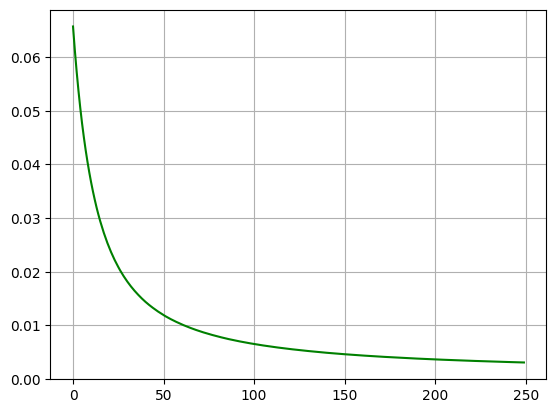

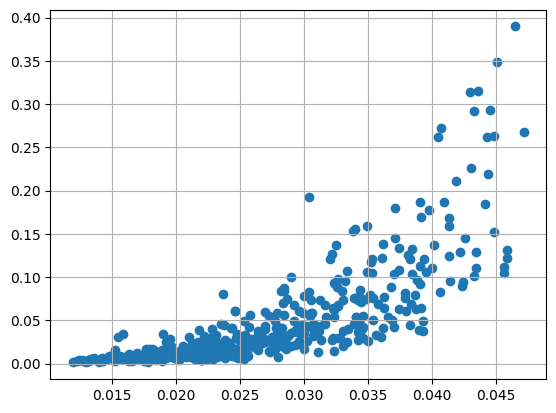

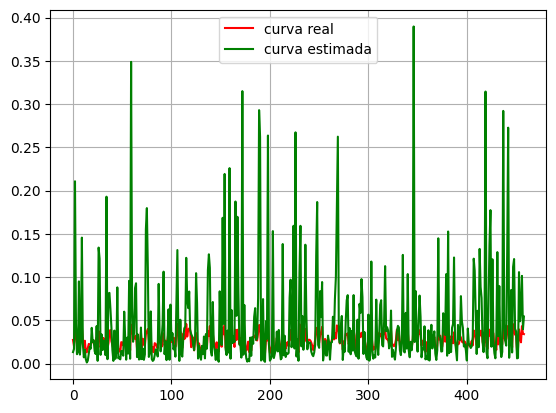

Los efectos independientes son:
 [[-1.8105927 ]
 [-1.2672316 ]
 [ 0.510995  ]
 [-0.9304514 ]
 [-1.2075756 ]
 [-1.0490454 ]
 [ 0.38213158]
 [-1.780181  ]
 [-1.0310282 ]]


In [ ]:
#Modelo 1
yd=madaline1.predict(XDn)
dfcorr2=pd.DataFrame(np.column_stack((yd,ydn)))
print("La correlación entre yd-ydn es:\n", dfcorr2.corr())

#Caída del error en el aprendizaje
ek1=history2.history['loss'] #Muestra el error en el aprendizaje

plt.figure()
plt.plot(ek1,'g')
plt.grid(True)
plt.show()

#scatter plot
plt.figure()
plt.scatter(ydn, yd, label = 'Grafico de correlacion')
plt.grid()
plt.show()

#figura entre curvas
plt.figure()
plt.plot(ydn, color = 'r', label = 'curva real')
plt.plot(yd, color = 'g', label = 'curva estimada')
plt.legend()
plt.grid()
plt.show()


#Efectos independientes
WC1=madaline1.get_weights()
W1=WC1[0]; C1=WC1[1]
a1=W1@C1 #Estos son los efectos independientes
print("Los efectos independientes son:\n", a1)


In [ ]:
#MODELO 1
Xnp=[[59.29, 16.17, 83.88, 42.66, 72.01, 6, 16.67, 3.36, 26.87]]
Xnpn=Xnp/np.max(XD,axis=0)
print("Los datos de entrada son:\n", Xnpn)
ypnp=madaline1.predict(Xnpn)
print("El score estimado es:\n", ypnp)

Los datos de entrada son:
 [[0.64884088 0.16438317 0.86937446 0.4485495  0.72364729 0.28571429
  0.27783333 0.0336     0.5374    ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
El score estimado es:
 [[0.04339858]]


**Modelo 2**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_74 (Dense)                │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2283  
Epoch 2/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2097  
Epoch 3/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1928 
Epoch 4/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1804 
Epoch 5/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1649  
Epoch 6/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1538 
Epoch 7/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1408  
Epoch 8/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1278 
Epoch 9/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1212  
Epoch 10/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1133  
Epoch 11/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1032 
Epoch 12/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0971 
Epoch 13/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0894 
Epoch 14/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0828 
Epoch 15/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

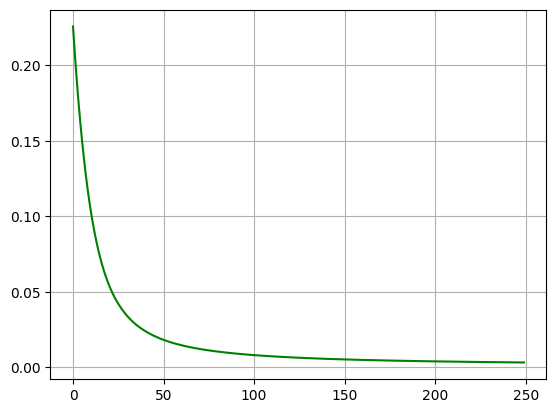

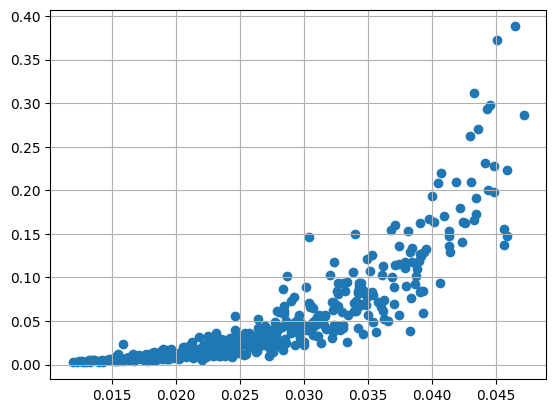

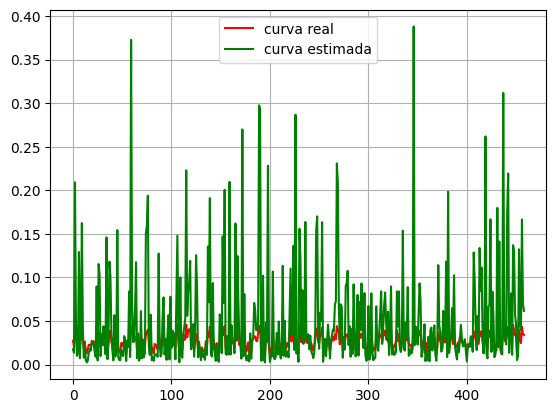

Los efectos independientes son:
 [[-1.4076852 ]
 [-0.6690692 ]
 [-1.451201  ]
 [-0.47572464]
 [-0.8928922 ]
 [-1.8078898 ]
 [-0.8185914 ]
 [-0.6792329 ]
 [-0.429025  ]]


In [ ]:
#MODELO 2
#np.random.seed(42)
madaline2=tf.keras.Sequential([
    tf.keras.layers.Dense(units=10,input_shape=(9,),use_bias=False, activation='relu'),
    tf.keras.layers.Dense(units=1,use_bias=False, activation='sigmoid')])

madaline2.load_weights('/content/drive/MyDrive/Eafit/Colab Notebooks - Analítica de Negocios/Bases de Datos/7. pesos_sigmoid_WACCL.weights.h5')

madaline2.summary()
madaline2.compile(optimizer='sgd',loss='mse')
history3=madaline2.fit(XDn,ydn2,epochs=250)

yd2=madaline2.predict(XDn)
dfcorr2=pd.DataFrame(np.column_stack((yd2,ydn2)))
print("La correlación entre yd2-ydn2 es:\n", dfcorr2.corr())

#Caída del error en el aprendizaje
ek2=history3.history['loss'] #Muestra el error en el aprendizaje

plt.figure()
plt.plot(ek2,'g')
plt.grid(True)
plt.show()

#scatter plot
plt.figure()
plt.scatter(ydn2, yd2, label = 'Grafico de correlacion')
plt.grid()
plt.show()

#figura entre curvas
plt.figure()
plt.plot(ydn2, color = 'r', label = 'curva real')
plt.plot(yd2, color = 'g', label = 'curva estimada')
plt.legend()
plt.grid()
plt.show()

#Efectos independientes
WC2=madaline2.get_weights()
W2=WC2[0]; C2=WC2[1]
a2=W2@C2 #Estos son los efectos independientes
print("Los efectos independientes son:\n", a2)

In [ ]:
#MODELO 2
Xnp=[[59.29, 16.17, 83.88, 42.66, 72.01, 6, 16.67, 3.36, 26.87]]
Xnpn=Xnp/np.max(XD,axis=0)
print("Los datos de entrada son:\n", Xnpn)
ypnp=madaline2.predict(Xnpn)
print("El score estimado es:\n", ypnp)

Los datos de entrada son:
 [[0.64884088 0.16438317 0.86937446 0.4485495  0.72364729 0.28571429
  0.27783333 0.0336     0.5374    ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
El score estimado es:
 [[0.01921909]]


**Modelo Autoencoder**

In [ ]:
# Selección de variables
nxl='/content/drive/MyDrive/Eafit/Colab Notebooks - Analítica de Negocios/Bases de Datos/7. pesos_autoencoder_BGD.weights.h5'
XDB = XDB[['ESG Score (2022)','Environmental Pillar Score( 2022)','Social Pillar Score (2022)','Governance Pillar Socre (2022)',
            ' WACC Short Term Debt Cost (2022)','WACC Long Term Debt Cost (2022)',
            'Board Gender Diversity (2022)',' Board Size (2022)','Female on Board (2022)',
            'Independant Board Members Score (2022)','Executive Members Gender Diversity (2022)']]
XDB=XDB.dropna()

XD=np.array(XDB) #Misma Entrada
XDn=XD/np.max(XD,axis=0) #Normalización
ydna=np.array(XDn)#Misma Salida

In [ ]:
madaline_sig=tf.keras.models.Sequential([
    tf.keras.layers.Dense(10,input_shape=(11,),activation='relu',use_bias=False), #Capa 1_ 10 regresiones lineales
    tf.keras.layers.Dense(11,activation='relu',use_bias=False)
]) #Capa 2: El núcleo o la salida del modelo

madaline_sig.summary()
madaline_sig.compile(optimizer='sgd',loss='mse') #sgd: Gradiente en descenso (Solve Descend Graident)
                                             #mse: Mean Square Error - Quiero que sea cero
                                             #Recorrer 100 veces l tabla de datos
                                             #Pronóstico al final del aprendizaje
history=madaline_sig.fit(XDn,XDn,epochs=250) #Misma entrada y misma salida
ydap=madaline_sig.predict(XDn) #Este es el pronóstico

#Las correlaciones son las siguientes
df=pd.DataFrame(np.column_stack((XDn,ydap)))
print("La correlación entre las variables es:\n",df.corr())
pd.DataFrame(df.corr()).to_excel('Correlaciones.xlsx')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 11)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220 (880.00 B)

 Trainable params: 220 (880.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1946  
Epoch 2/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1904  
Epoch 3/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1809 
Epoch 4/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1723 
Epoch 5/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1712 
Epoch 6/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1604 
Epoch 7/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1574 
Epoch 8/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1490 
Epoch 9/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1484 
Epoch 10/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1426 
Epoch 11/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1412 
Epoch 12/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1395 
Epoch 13/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1336 
Epoch 14/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1314 
Epoch 15/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - l

**Analisis:**
Esta base de datos muestra el cumplimiento de las empresas con la diversidad y equidad de genero en las empresas. Se establecen dos modelos MADALINE usando las bases de datos WACCS y WACCL para analizar la relacion de las variables de entrada (listados a continuacion) con la variable de comparacion a corto y largo plazo. Las variables de entrada corresponden a indicadores de practicas de sostenibilidad de la empresa, factores sociales, y financieros los cuales fueron normalizados para la ejecucion de los dos modelos. Estos modelos usaran funciones lineales "relu".

**Las variables de entrada que se toman en cuenta para el modelo corresponden a:**

Puntajes ESG: Se mide el cumplimiento de las empresas con los pilares ESG  como los ambientales, sociales y de gobernanza en temas relacionados con la mejora del ESG.

Miembros independientes de junta directiva: Número de miembros independientes de la junta dividido en respecto a los miembros totales de la junta directiva.

Tamaño de la junta directiva: La cantidad de peronas en la junta directiva.

Diversidad de políticas en junta directiva: Dice si la empresa tiene políticas que tienen que ver con la diversidad de género.

Igualdad de género: Dice cumplimiento de los postulados establecidos en el Objetivo de Desarrollo Sostenible número 5, el objetivo de  igualdad de género.

Diversidad de género en miembros ejecutivo: Mujeres que ocupan cargos ejecutivos dentro de una empresa pero se muestra en porcentaje.

Diversidad de género en junta directiva: Indica el porcentaje de mujeres que forman parte de la junta directiva la empresa.

*Todas las variables exclusivamente para el 2022*

**MODELO 1: Corto plazo**
El primer modelo de WACCS utilizando el modelo Madaline, se utilizaron las mismas 11 variables explicadas anteriormente.

Valor del score estimado para la empresa con las variables [59.29, 16.17, 83.88, 42.66, 72.01, 6, 16.67, 3.36, 26.87] es de **0.043.**

La predicción del modelo, vemos que el valor de 0.76 que es un buen nivel mostrando la prediccion esta prediciendo valores mas altos que los valores reales que esta siendo evidenciado.

Mirando los ejectos independientes podemos destacar que la variable ESG Score con un valor negativo (-1.81) hace que el costo a corto plazo baje. Como es tan grande se puede asumir que la importancia de la variable es mayor respecto a otras con variables. Aqui vemos algunos valores positivos, los cuales debemos recordar que significan que cuando estas variables son positivas entonces el costo sube.


**MODELO 2: Largo plazo**
El segundo modelo de WACCL utilizando el modelo Madaline, se utilizaron las mismas 11 variables explicadas anteriormente.

Valor del score estimado para la empresa con las variables [59.29, 16.17, 83.88, 42.66, 72.01, 6, 16.67, 3.36, 26.87] es de **0.019.**

Mirando la predicción del modelo 2 vemos una MSE alta de 0.83, lo cual nos indica que las predicciones estan mas lejos que los valores reales, lo cual también podemos evidenciar en la grafica que vemos en este modelo.

Analizando los ejectos independientes podemos ver que una variable importante de este modelo es el tamaño de la junta directa con un valor negativo (-1.81) y entonces vemos que esta variable baja el costo a largo plazo. Vemos que todos los variables de este modelo estan negativas, entonces podemos asumir que todas las variables, a largo plazo, van a afectar a las empresas aumentando el costo respecto a este tema de la equidad de genero.

**Modelo Autoencoder:**

En el modelo autoenconder se usan las mismas 11 variables para compararse entre ellas 11, nos arroja una tabla el cual podemos ver la relación entre estas variables y evidenciar estas correlaciones entre las variables. Este modelo se lee con las relaciones al revez que los modelos de corto y largo plazo en terminos de su relación entre ellas.

Las celdas con un 1 indican una correlación perfecta, pero, solo vemos esto entre las variables de entrada y salida que son la misma (se puede ignorar este valor cuando pase esto).

En general, las celdas con valores con correlaciones altas indican una fuerte relación entre varias variables. Unas variables desacables por su relación son la 0 (ESG Score) y 2 (Social Pillar Score) con un valor de 0.93 y significa que estas variables tienden a tener el mismo efecto cuando suben o bajan. Por otro lado también vemos variables que entre ellas comparten una relación negativa, lo cuales son por ejemplo la 0 (ESG Score) y la 4 (WACC Short Term Debt Cost) con un valor de -0.86 lo cual indica que entre más puntaje ESG haya menos es el costo de una deuda a largo plazo.
